In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv

In [60]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [61]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [63]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [64]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [65]:
df["Churn"]=df["Churn"].map({"No":0,"Yes":1 })

In [66]:
#STEP 2: Data Cleaning

In [67]:
df = df.drop("customerID",axis=1)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [69]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [70]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [71]:
df = df.dropna()

In [72]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [73]:
df = pd.get_dummies(df, drop_first=True)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

In [75]:
#3 STEP 3: EDA (Visualization + Insights)

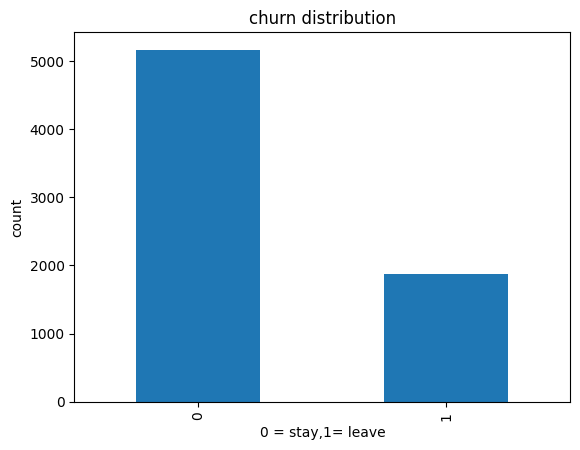

In [76]:
df["Churn"].value_counts().plot(kind="bar")
plt.title("churn distribution")
plt.xlabel("0 = stay,1= leave")
plt.ylabel("count")
plt.show()

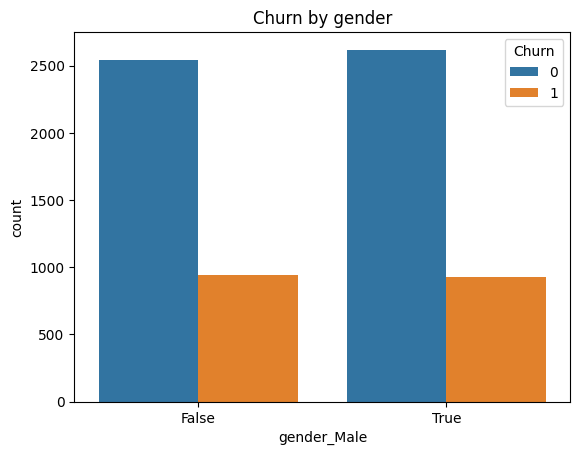

In [77]:
sns.countplot(x="gender_Male",hue="Churn",data=df)
plt.title("Churn by gender")
plt.show()

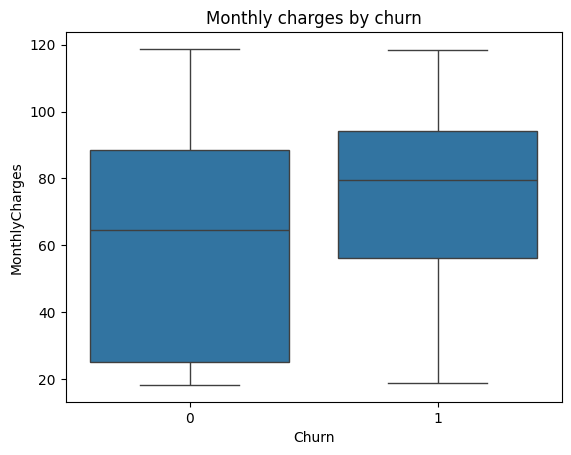

In [78]:
sns.boxplot(x="Churn",y="MonthlyCharges",data=df)
plt.title("Monthly charges by churn")
plt.show()


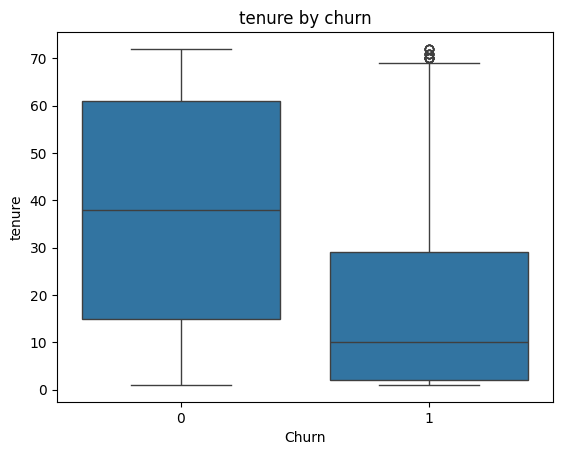

In [79]:
sns.boxplot(x="Churn",y="tenure",data=df)
plt.title("tenure by churn")
plt.show()


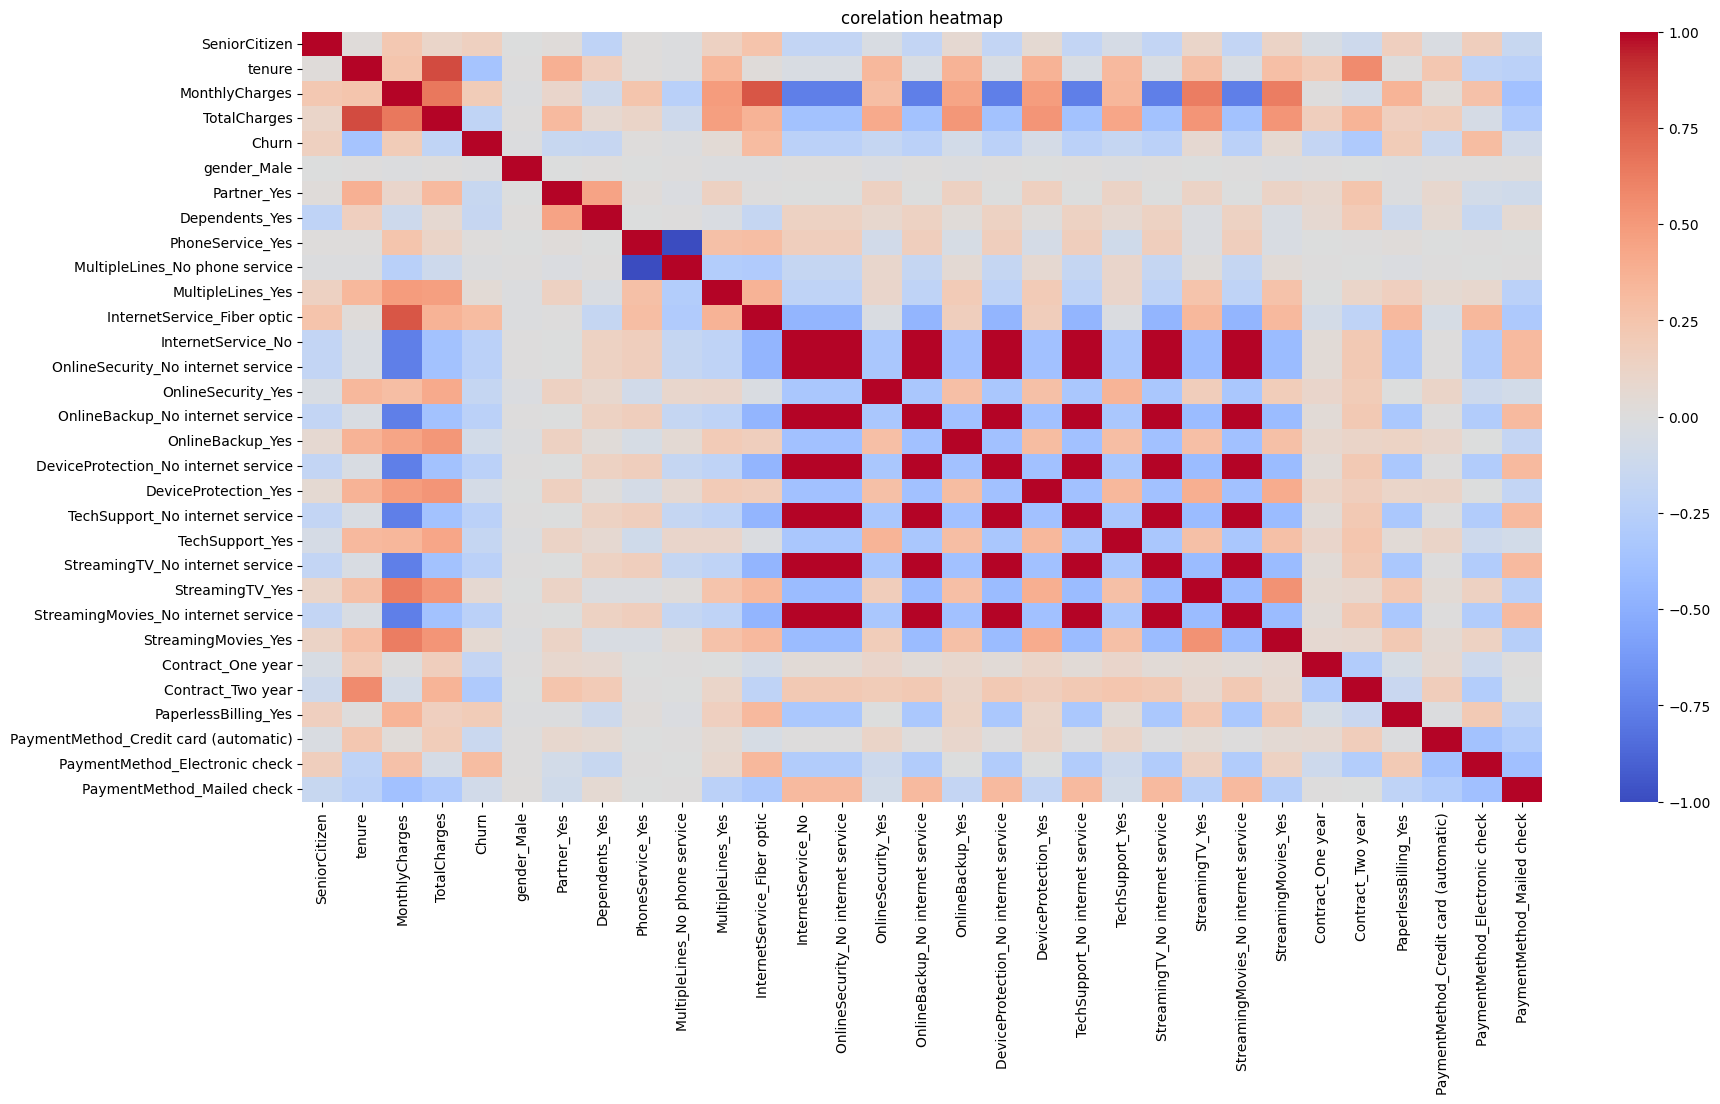

In [80]:
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("corelation heatmap")
plt.show()

In [81]:
#feature selection
x = df.drop("Churn", axis=1)#input coloums without target
y = df["Churn"]#prediction we need

In [82]:
# for train test split we use sikit

In [83]:
from sklearn.model_selection import train_test_split

In [84]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [85]:
print("xtrain",x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

xtrain (5625, 30)
(1407, 30)
(5625,)
(1407,)


In [86]:
print(y_train.value_counts())

Churn
0    4130
1    1495
Name: count, dtype: int64


In [87]:
#first modal we are using los=gistic regretion for binary classification

In [88]:
from sklearn.linear_model import LogisticRegression

In [89]:
model = LogisticRegression(max_iter=1000)

In [90]:
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [91]:
y_pred = model.predict(x_test)

In [92]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [93]:
accuracy = accuracy_score(y_test,y_pred)
print("accuracy",accuracy)

accuracy 0.7874911158493249


In [94]:
comparison = pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
comparison.head(10)

,Actual,Predicted
2481,0,0
6784,0,0
6125,1,1
3052,0,0
4099,0,0
3223,0,0
3774,0,0
3469,0,1
3420,0,0
1196,0,0


In [95]:
#STEP 6: Model Evaluation

In [96]:
from sklearn.metrics import confusion_matrix

In [97]:
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[915 118]
 [181 193]]


<function matplotlib.pyplot.show(close=None, block=None)>

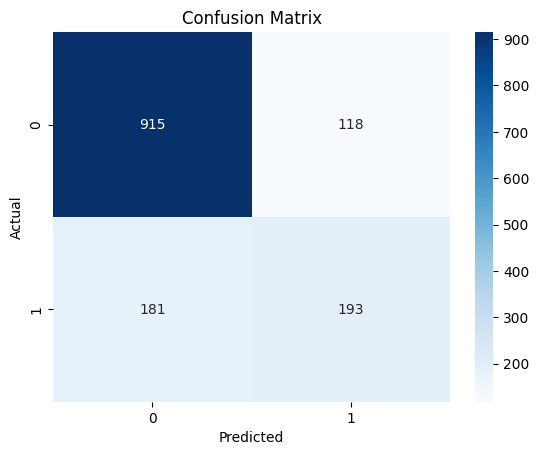

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show

In [99]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [100]:
###4. ROC Curve + AUC


###This shows:

###How good the model is overall

In [101]:
from sklearn.metrics import roc_curve, auc

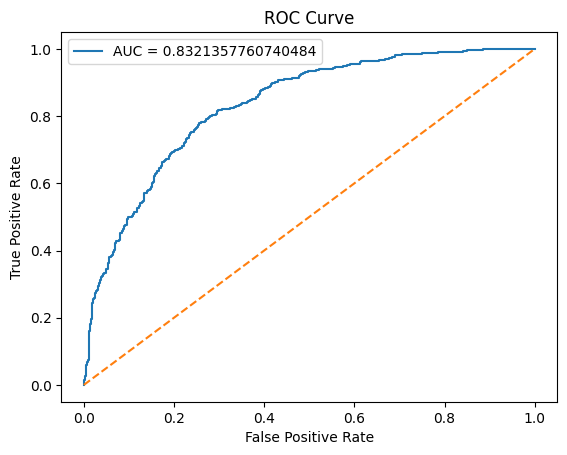

In [102]:
y_prob = model.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [103]:
#STEP 7: Random Forest Classifier

In [104]:
from sklearn.ensemble import RandomForestClassifier

In [105]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [106]:
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [107]:
rf_pred = rf_model.predict(x_test)

In [108]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7853589196872779


In [109]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [110]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[927 106]
 [196 178]]


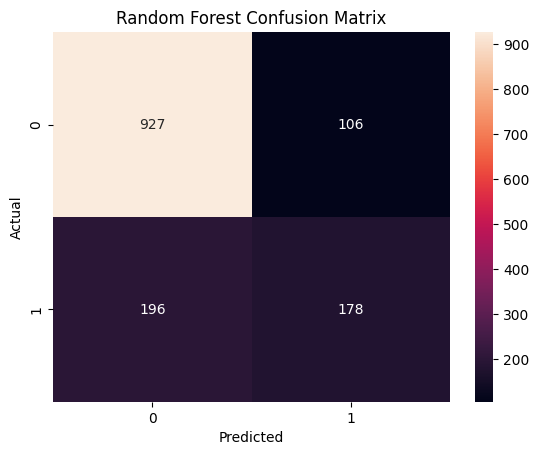

In [111]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(rf_cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [112]:
#COLAB STEP 8: XGBoost (Industry-Level Model)

In [113]:
from xgboost import XGBClassifier

In [114]:
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss'
)

In [116]:
xgb_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:43:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [117]:
xgb_pred = xgb_model.predict(x_test)

In [118]:
from sklearn.metrics import accuracy_score

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7739872068230277


In [119]:
from sklearn.metrics import classification_report

print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [120]:
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(y_test, xgb_pred)

print(xgb_cm)

[[903 130]
 [188 186]]


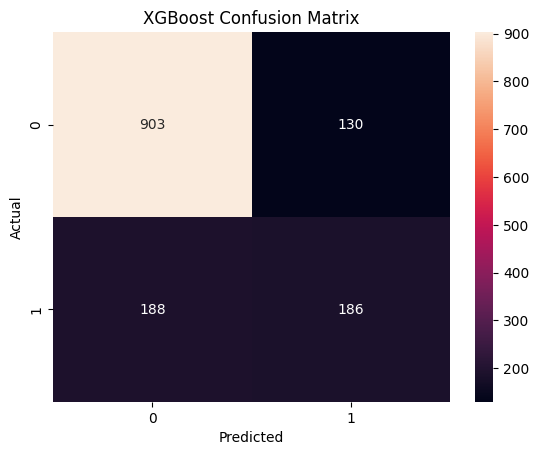

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(xgb_cm, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

In [125]:
print("Logistic Regression:", accuracy_score(y_test, y_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.7874911158493249
Random Forest: 0.7853589196872779
XGBoost: 0.7739872068230277


In [126]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# Create comparison table
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

# Sort by F1 Score (Best model on top)
comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

# Show results
comparison_df

,Model,Accuracy,Recall,F1 Score
0,Logistic Regression,0.787491,0.516043,0.563504
1,Random Forest,0.785359,0.475936,0.541033
2,XGBoost,0.773987,0.497326,0.539130


In [127]:
best_row = comparison_df.loc[comparison_df["F1 Score"].idxmax()]

print("Best Model:")
print(best_row)

Best Model:
Model       Logistic Regression
Accuracy               0.787491
Recall                 0.516043
F1 Score               0.563504
Name: 0, dtype: object


In [128]:
best_model = model

In [131]:
import joblib
joblib.dump(best_model, "best_churn_model.pkl")

['best_churn_model.pkl']

In [133]:
loaded_model = joblib.load("best_churn_model.pkl")

In [135]:
sample = x_test.iloc[0:1]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [137]:
final_pred = loaded_model.predict(x_test)

from sklearn.metrics import accuracy_score

print("Final Accuracy:", accuracy_score(y_test, final_pred))

Final Accuracy: 0.7874911158493249
